# Clasificación y Caracterización de Géneros Musicales mediante Procesamiento Digital de Señales y Machine Learning

Este notebook consolida y explica paso a paso el proyecto de procesamiento de señales de audio y clasificación de géneros musicales utilizando el dataset **GTZAN**.

## Objetivos del Trabajo Práctico:
1. **Visualizar y caracterizar** señales de audio en el dominio del tiempo y de la frecuencia.
2. **Analizar la respuesta temporo-frecuencial** mediante espectrogramas (STFT) y **Transformada Wavelet Continua (CWT)**.
3. **Diseñar y aplicar filtros** (pasa-bajos y pasa-altos) para evaluar la importancia de diferentes bandas de frecuencia en la clasificación.
4. **Extraer descriptores característicos** (Spectral Centroid, Spectral Bandwidth, Zero Crossing Rate, RMS y MFCCs) que resuman las propiedades de las señales.
5. **Analizar la autocorrelación** para estudiar propiedades rítmicas y periódicas.
6. **Entrenar y comparar modelos de Machine Learning** (Random Forest y Support Vector Machine - SVM) para clasificar canciones entre 10 géneros musicales.

## Configuración del Entorno y Carga de Datos

Comenzamos importando las librerías necesarias para el procesamiento de audio, análisis numérico, visualización y aprendizaje automático.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fft import fft
from scipy.signal import butter, sosfiltfilt, correlate
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from IPython.display import Audio, display

# Función auxiliar para reproducir audio en el notebook
def reproducir_audio(audio, sr, etiqueta):
    print(f"Reproducir {etiqueta}:")
    display(Audio(audio, rate=sr))

# Configuración de Matplotlib para visualización interactiva y estética
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)

# Definir la ruta del dataset
DATASET_PATH = Path("Data/genres_original")
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## Etapa 2: Visualización en el Dominio del Tiempo

La primera aproximación al análisis de audio consiste en estudiar la señal en el dominio del tiempo. La amplitud del audio representa las variaciones de presión acústica a lo largo del tiempo.

Cargamos un archivo de muestra de cada uno de cuatro géneros distintos: **blues**, **classical**, **jazz** y **metal**. Analizaremos y compararemos su amplitud, dinámica y estructura general.

Género: blues | Frecuencia de muestreo: 22050 Hz | Muestras: 661794 | Duración: 30.01 s
Género: classical | Frecuencia de muestreo: 22050 Hz | Muestras: 661794 | Duración: 30.01 s
Género: jazz | Frecuencia de muestreo: 22050 Hz | Muestras: 661794 | Duración: 30.01 s
Género: metal | Frecuencia de muestreo: 22050 Hz | Muestras: 661504 | Duración: 30.00 s


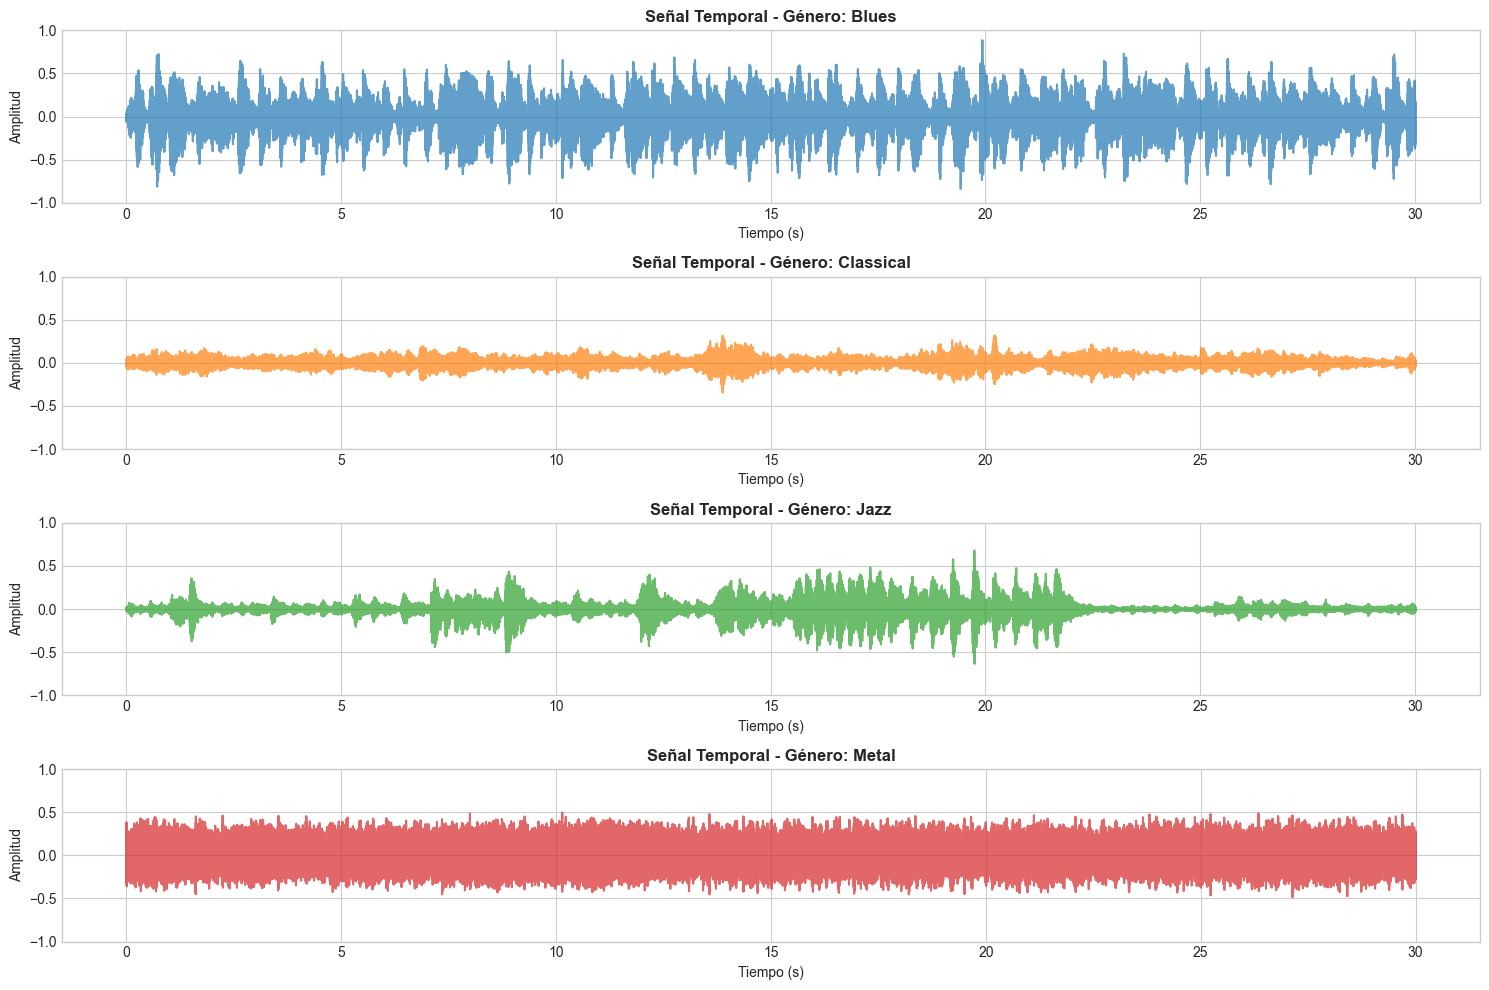

In [2]:
canciones_muestra = {
    "blues": "blues.00000.wav",
    "classical": "classical.00000.wav",
    "jazz": "jazz.00000.wav",
    "metal": "metal.00000.wav"
}

audios_cargados = {}

for genero, archivo in canciones_muestra.items():
    ruta = DATASET_PATH / genero / archivo
    if ruta.exists():
        audio, sr = librosa.load(ruta, sr=None)
        audios_cargados[genero] = (audio, sr)
        print(f"Género: {genero} | Frecuencia de muestreo: {sr} Hz | Muestras: {len(audio)} | Duración: {len(audio)/sr:.2f} s")
    else:
        print(f"No se encontró el archivo para {genero} en {ruta}")

# Graficar las señales temporales
plt.figure(figsize=(15, 10))
for idx, (genero, (audio, sr)) in enumerate(audios_cargados.items(), 1):
    plt.subplot(4, 1, idx)
    # Crear vector de tiempo en segundos
    tiempo = np.linspace(0, len(audio)/sr, num=len(audio))
    plt.plot(tiempo, audio, alpha=0.7, color=f"C{idx-1}")
    plt.title(f"Señal Temporal - Género: {genero.capitalize()}", fontsize=12, fontweight='bold')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.ylim(-1, 1)
    plt.grid(True)
plt.tight_layout()
plt.show()

## Etapa 3: Análisis en Frecuencia (Transformada Rápida de Fourier - FFT)

La Transformada Rápida de Fourier (FFT) permite transformar la señal del dominio del tiempo al dominio de la frecuencia. Con esto podemos analizar qué componentes de frecuencia (tonos graves, medios, agudos) componen la señal y con qué intensidad.

Compararemos los espectros de magnitud de los géneros seleccionados. Se espera que géneros como el **metal** contengan mucha energía en frecuencias altas debido a distorsiones y platillos, mientras que la música **clásica** suele concentrarse en frecuencias más bajas y armónicos definidos.

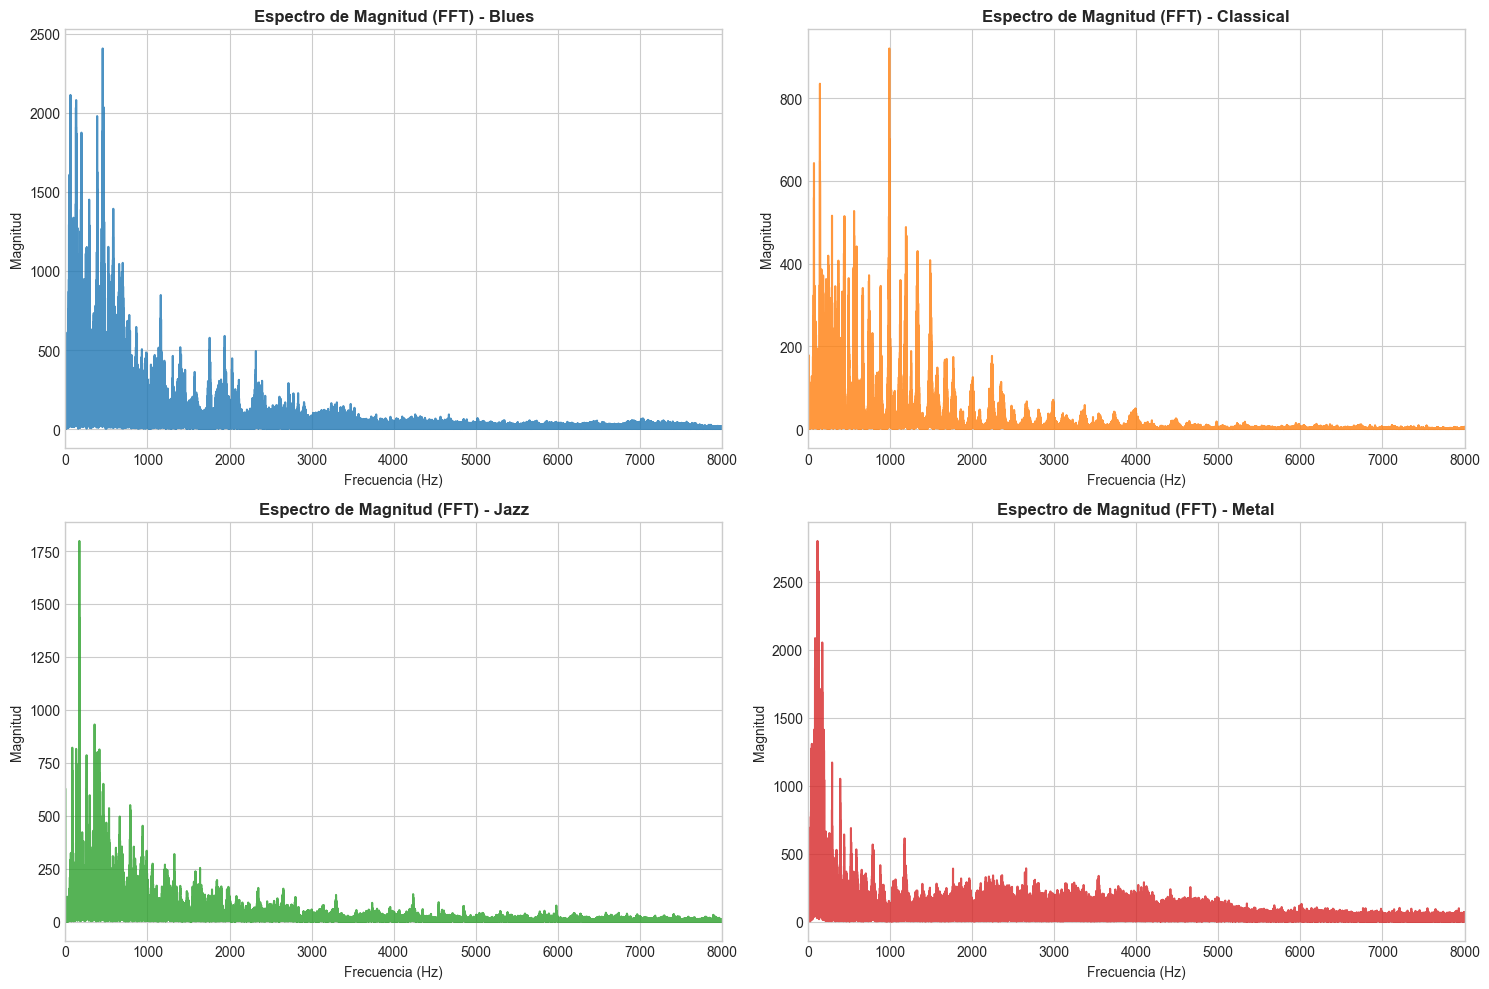

In [3]:
plt.figure(figsize=(15, 10))
for idx, (genero, (audio, sr)) in enumerate(audios_cargados.items(), 1):
    N = len(audio)
    # Calcular FFT
    X = fft(audio)
    # Obtener el vector de frecuencias
    freqs = np.fft.fftfreq(N, d=1/sr)
    
    # Graficar la mitad del espectro (frecuencias positivas)
    plt.subplot(2, 2, idx)
    plt.plot(freqs[:N//2], np.abs(X[:N//2]), color=f"C{idx-1}", alpha=0.8)
    plt.title(f"Espectro de Magnitud (FFT) - {genero.capitalize()}", fontsize=12, fontweight='bold')
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.xlim(0, 8000) # Centrado en el rango audible más relevante
    plt.grid(True)
plt.tight_layout()
plt.show()

## Etapa 4: Análisis Tiempo-Frecuencia (Espectrogramas - STFT)

Dado que la música es una señal no estacionaria (su contenido de frecuencia cambia con el tiempo), la FFT global pierde la información temporal. La **Transformada de Fourier de Tiempo Corto (STFT)** soluciona esto dividiendo la señal en ventanas de tiempo y aplicando la FFT a cada ventana.

Un **espectrograma** es la representación visual de la magnitud de la STFT, donde el eje X representa el tiempo, el eje Y representa la frecuencia (generalmente en escala logarítmica para alinearse con la percepción humana) y el color representa la amplitud en decibeles (dB).

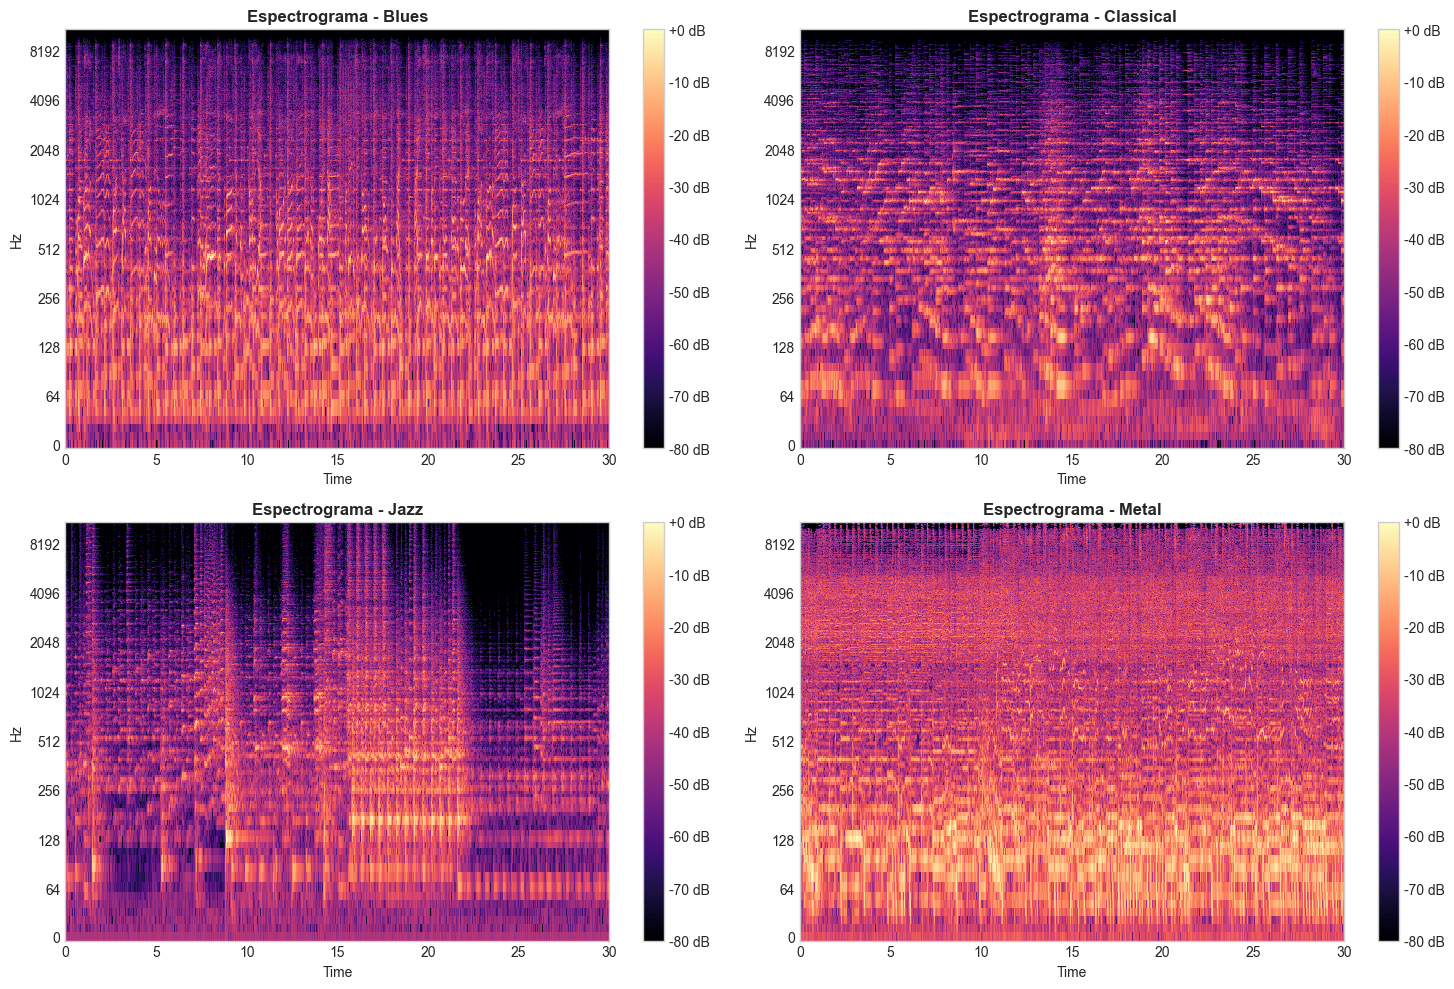

In [4]:
plt.figure(figsize=(15, 10))
for idx, (genero, (audio, sr)) in enumerate(audios_cargados.items(), 1):
    # Calcular STFT
    stft = librosa.stft(audio)
    # Convertir a escala de decibeles
    espectrograma = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
    
    plt.subplot(2, 2, idx)
    librosa.display.specshow(espectrograma, sr=sr, x_axis="time", y_axis="log", cmap="magma")
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Espectrograma - {genero.capitalize()}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Etapa 4.5: Análisis Tiempo-Frecuencia Alternativo - Transformada Wavelet Continua (CWT)

Una alternativa muy potente a la STFT para el análisis tiempo-frecuencia es la **Transformada Wavelet Continua (CWT)**. 
A diferencia de la STFT, que utiliza ventanas temporales de tamaño fijo (lo que impone una resolución uniforme en todo el plano tiempo-frecuencia), la CWT utiliza una ventana de tamaño variable (las "wavelets" o ondículas):
* **Frecuencias altas:** Las wavelets se contraen (escalas pequeñas), lo que proporciona una excelente resolución temporal pero menor resolución frecuencial.
* **Frecuencias bajas:** Las wavelets se dilatan (escalas grandes), lo que proporciona una excelente resolución frecuencial pero menor resolución temporal.

Esta propiedad de "multi-resolución" es ideal para señales de audio y música, ya que el sistema auditivo humano percibe las frecuencias de forma logarítmica.

El resultado gráfico de la CWT se denomina **Escalograma**. A continuación, calcularemos la CWT utilizando una wavelet Morlet ('morl') sobre una ventana de 1 segundo de dos géneros musicales contrastantes (**metal** y **classical**).

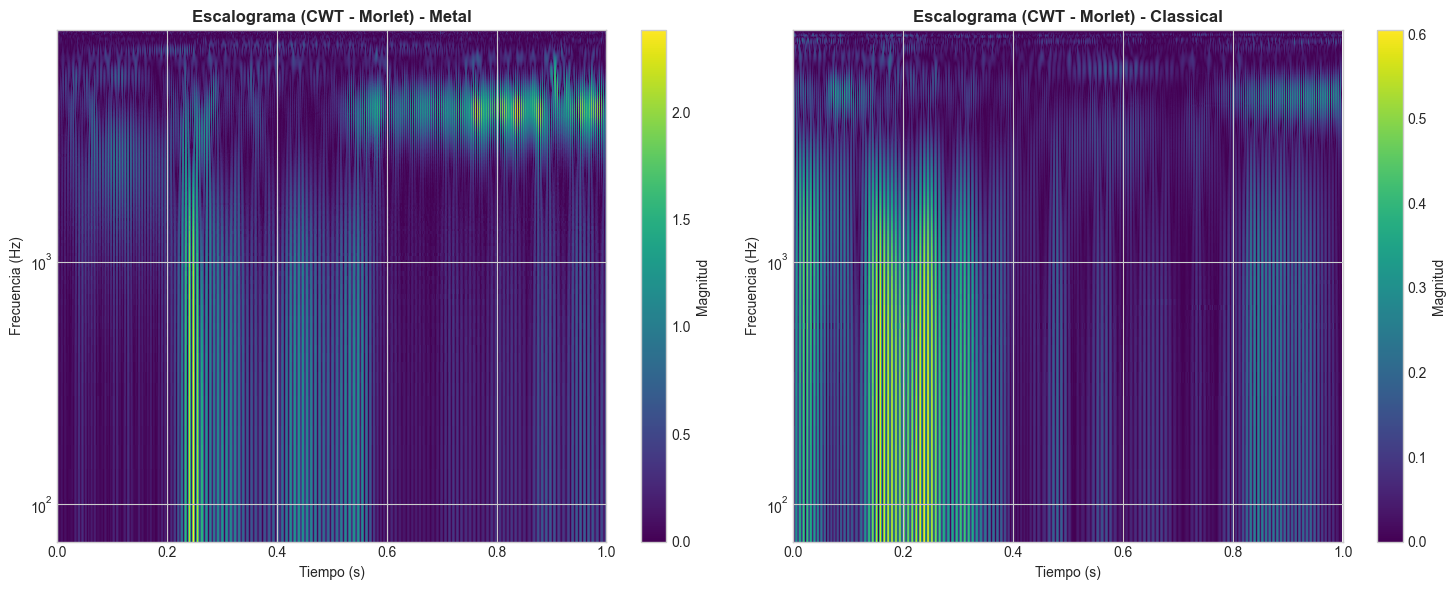

In [5]:
import pywt

# Tomaremos un fragmento de 1 segundo (del segundo 2 al 3) para visualizar con alta definición
duracion_seg = 1.0
plt.figure(figsize=(15, 6))

for idx, genero in enumerate(["metal", "classical"]):
    audio, sr = audios_cargados[genero]
    
    # Extraer el segmento
    inicio_muestra = int(2.0 * sr)
    fin_muestra = int((2.0 + duracion_seg) * sr)
    segmento = audio[inicio_muestra:fin_muestra]
    
    # Definir escalas (de 2 a 256)
    scales = np.arange(2, 256)
    wavelet = 'morl'
    
    # Calcular CWT
    coefs, freqs = pywt.cwt(segmento, scales, wavelet, sampling_period=1/sr)
    
    # Graficar escalograma
    plt.subplot(1, 2, idx + 1)
    # Mostramos la magnitud de los coeficientes de CWT
    plt.imshow(np.abs(coefs), extent=[0, duracion_seg, freqs[-1], freqs[0]], 
               cmap='viridis', aspect='auto', interpolation='nearest')
    plt.yscale('log') # Escala logarítmica para frecuencias
    plt.title(f"Escalograma (CWT - Morlet) - {genero.capitalize()}", fontsize=12, fontweight='bold')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Frecuencia (Hz)")
    plt.colorbar(label="Magnitud")

plt.tight_layout()
plt.show()

## Etapa 5: Filtrado de Señales (Filtros Butterworth IIR)

El filtrado permite aislar o atenuar rangos específicos de frecuencias. Diseñaremos y aplicaremos filtros Butterworth de tipo IIR (Infinite Impulse Response) de 4.º orden usando `scipy.signal.butter`.
* **Filtro Pasa-bajos (Lowpass):** Deja pasar las frecuencias inferiores a la frecuencia de corte (2000 Hz) y atenúa las superiores.
* **Filtro Pasa-altos (Highpass):** Deja pasar las frecuencias superiores a la frecuencia de corte (2000 Hz) y atenúa las inferiores.

Evaluaremos el efecto del filtrado de forma gráfica comparando la señal original con las señales filtradas.

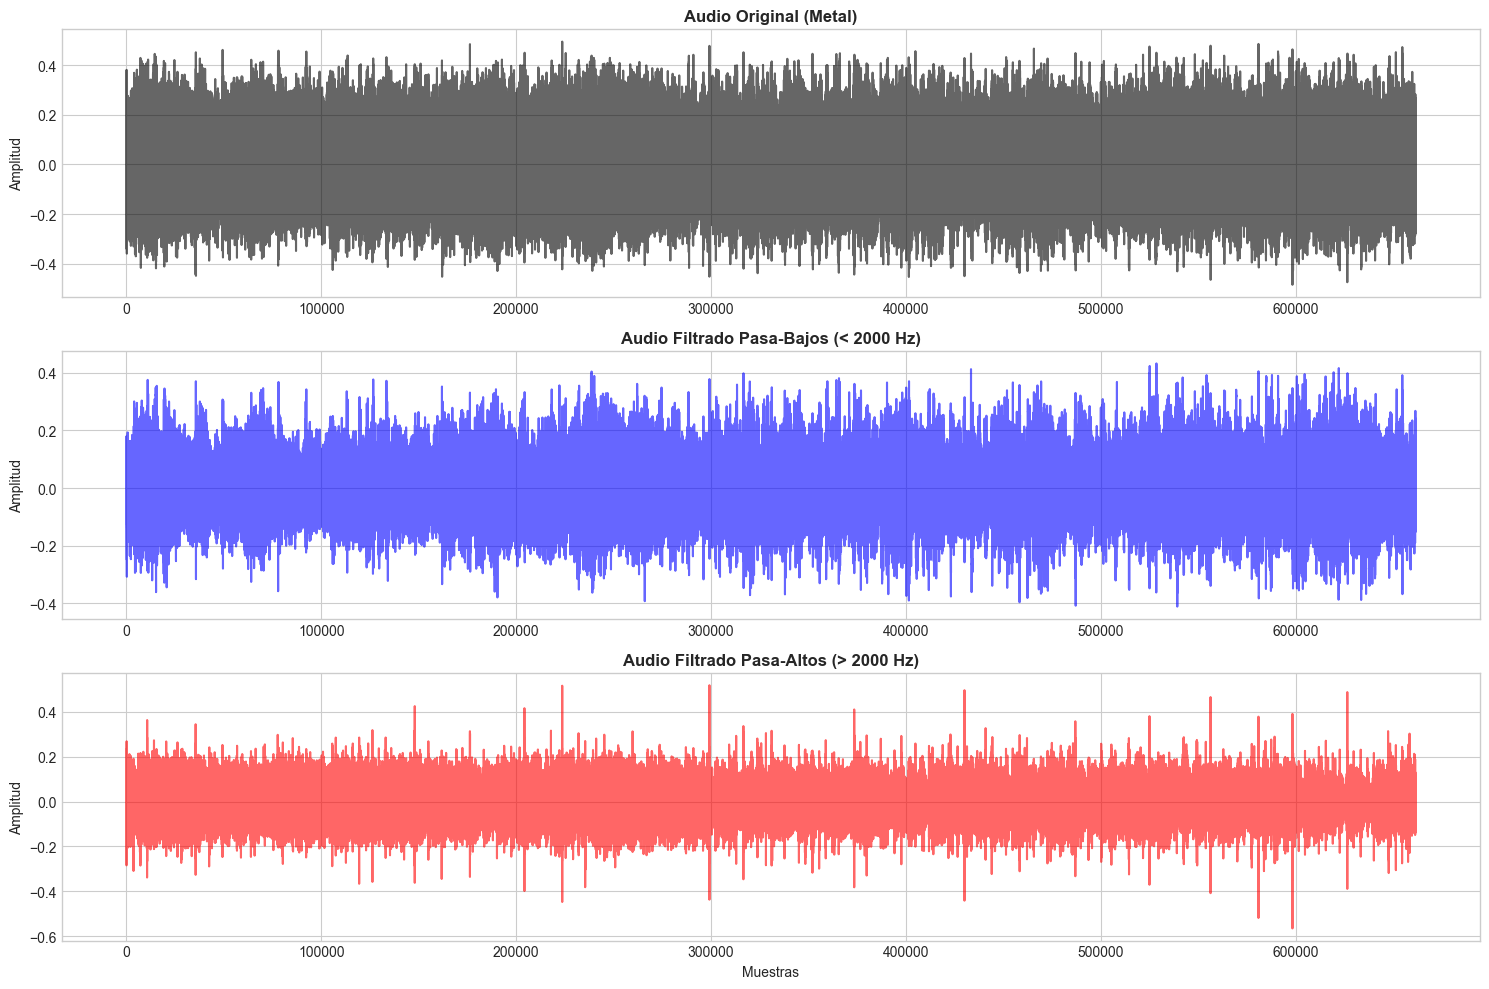

In [6]:
# Tomamos una canción de muestra (ej. metal) para ilustrar el filtrado
genero_filtro = "metal"
audio_orig, sr_orig = audios_cargados[genero_filtro]

# Parámetros del filtro
frecuencia_corte = 2000  # Hz
orden = 4
nyquist = sr_orig / 2
frecuencia_normalizada = frecuencia_corte / nyquist

# Diseñar filtros pasabajos y pasaaltos
b_low, a_low = butter(N=orden, Wn=frecuencia_normalizada, btype="low")
b_high, a_high = butter(N=orden, Wn=frecuencia_normalizada, btype="high")

# Aplicar filtros usando sosfiltfilt (fase lineal y sin distorsión de fase)
audio_lowpass = sosfiltfilt(butter(orden, frecuencia_normalizada, btype="low", output="sos"), audio_orig)
audio_highpass = sosfiltfilt(butter(orden, frecuencia_normalizada, btype="high", output="sos"), audio_orig)

# Graficar comparación en el dominio del tiempo
plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plt.plot(audio_orig, color="black", alpha=0.6)
plt.title("Audio Original (Metal)", fontsize=12, fontweight='bold')
plt.ylabel("Amplitud")

plt.subplot(3, 1, 2)
plt.plot(audio_lowpass, color="blue", alpha=0.6)
plt.title(f"Audio Filtrado Pasa-Bajos (< {frecuencia_corte} Hz)", fontsize=12, fontweight='bold')
plt.ylabel("Amplitud")

plt.subplot(3, 1, 3)
plt.plot(audio_highpass, color="red", alpha=0.6)
plt.title(f"Audio Filtrado Pasa-Altos (> {frecuencia_corte} Hz)", fontsize=12, fontweight='bold')
plt.xlabel("Muestras")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

### Comparación de Espectrogramas antes y después de Filtrar

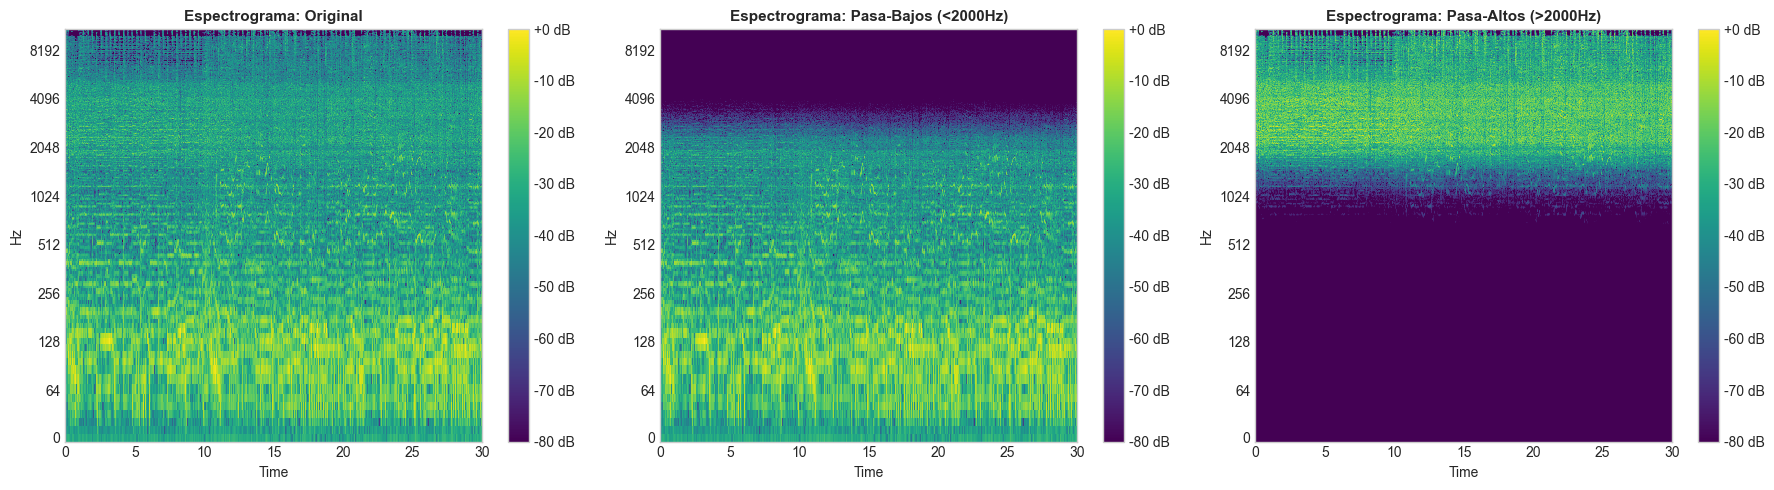

Reproducir Original (Metal):


Reproducir Filtrado Pasa-Bajos (<2000Hz):


Reproducir Filtrado Pasa-Altos (>2000Hz):


In [7]:
# Graficar espectrogramas de original vs filtrados
plt.figure(figsize=(18, 5))

# Original
stft_orig = librosa.amplitude_to_db(np.abs(librosa.stft(audio_orig)), ref=np.max)
plt.subplot(1, 3, 1)
librosa.display.specshow(stft_orig, sr=sr_orig, x_axis="time", y_axis="log", cmap="viridis")
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma: Original", fontsize=11, fontweight='bold')

# Pasa-bajos
stft_low = librosa.amplitude_to_db(np.abs(librosa.stft(audio_lowpass)), ref=np.max)
plt.subplot(1, 3, 2)
librosa.display.specshow(stft_low, sr=sr_orig, x_axis="time", y_axis="log", cmap="viridis")
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma: Pasa-Bajos (<2000Hz)", fontsize=11, fontweight='bold')

# Pasa-altos
stft_high = librosa.amplitude_to_db(np.abs(librosa.stft(audio_highpass)), ref=np.max)
plt.subplot(1, 3, 3)
librosa.display.specshow(stft_high, sr=sr_orig, x_axis="time", y_axis="log", cmap="viridis")
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma: Pasa-Altos (>2000Hz)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Reproducir audios para notar las diferencias auditivas del filtrado
reproducir_audio(audio_orig, sr_orig, "Original (Metal)")
reproducir_audio(audio_lowpass, sr_orig, "Filtrado Pasa-Bajos (<2000Hz)")
reproducir_audio(audio_highpass, sr_orig, "Filtrado Pasa-Altos (>2000Hz)")

## Etapa 6: Autocorrelación de la Señal

La autocorrelación mide la similitud de una señal con una versión desplazada (retrasada) de sí misma en función del retraso (lag). En audio, la autocorrelación es muy útil para detectar periodicidades asociadas al pitch (frecuencia fundamental) y al tempo (ritmo, bpm).

Graficaremos la autocorrelación de una señal muy rítmica (**metal**) y una señal con menor periodicidad rítmica estricta (**classical**). Usaremos una ventana de los primeros 5 segundos de audio para facilitar la visualización del retardo.

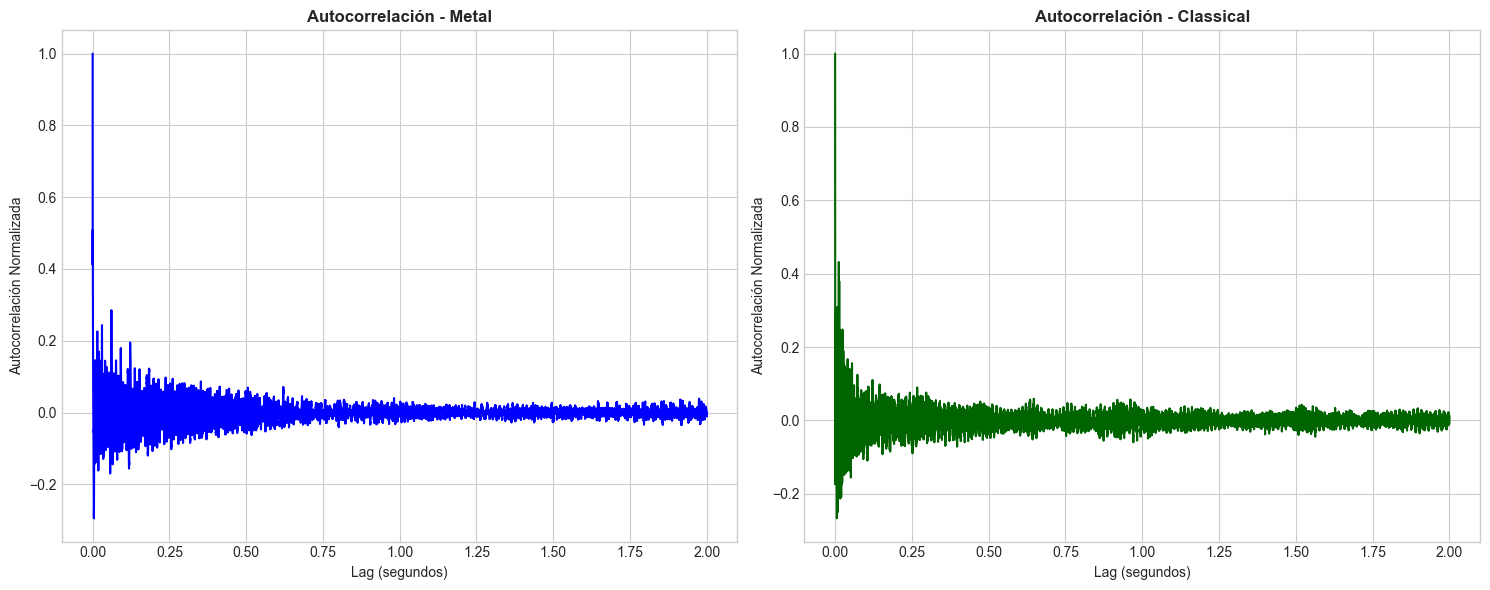

In [8]:
plt.figure(figsize=(15, 6))

for idx, genero in enumerate(["metal", "classical"]):
    audio, sr = audios_cargados[genero]
    # Tomar una ventana de 5 segundos
    ventana_audio = audio[:5 * sr]
    
    # Calcular autocorrelación
    # max_size limita el rango de lags a calcular para ver periodicidad clara (hasta 2 segundos)
    r = librosa.autocorrelate(ventana_audio, max_size=sr * 2)
    lags = np.arange(len(r)) / sr  # convertir a segundos
    
    plt.subplot(1, 2, idx + 1)
    plt.plot(lags, r / np.max(r), color="blue" if genero == "metal" else "darkgreen")
    plt.title(f"Autocorrelación - {genero.capitalize()}", fontsize=12, fontweight='bold')
    plt.xlabel("Lag (segundos)")
    plt.ylabel("Autocorrelación Normalizada")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Etapa 7: Extracción de Características (Feature Extraction)

Para entrenar un clasificador de Machine Learning, debemos resumir los datos de audio continuos de alta dimensión en un vector de características numéricas compactas.
Extraeremos los siguientes descriptores a nivel de frame y luego calcularemos su promedio a lo largo de toda la canción:
1. **Spectral Centroid (Centroide Espectral):** Indica dónde se encuentra el "centro de gravedad" de las frecuencias. Está correlacionado con el brillo del sonido.
2. **Spectral Bandwidth (Ancho de Banda Espectral):** Mide la dispersión espectral del sonido alrededor del centroide.
3. **Zero Crossing Rate (Tasa de Cruces por Cero):** La frecuencia con la que la señal cambia de signo. Sonidos con ruido (como platillos o distorsión) tienen un ZCR alto.
4. **RMS (Root Mean Square Energy):** La energía media efectiva de la señal en el tiempo.
5. **MFCCs (Coeficientes Cepstrales en las Frecuencias de Mel):** Coeficientes que representan la envolvente espectral del sonido, modelando la percepción del oído humano. Usaremos 13 coeficientes.

A continuación, se muestra cómo se extraen para un audio individual.

In [9]:
# Ejemplo de función para extraer características de un audio individual
def extraer_caracteristicas_ejemplo(audio, sr):
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
    rms = np.mean(librosa.feature.rms(y=audio))
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_means = np.mean(mfccs, axis=1)
    
    features = {
        "centroid": centroid,
        "bandwidth": bandwidth,
        "zcr": zcr,
        "rms": rms
    }
    for i, val in enumerate(mfcc_means, 1):
        features[f"mfcc_{i}"] = val
    return features

# Probar la función con la muestra de metal
ejemplo = extraer_caracteristicas_ejemplo(audios_cargados["metal"][0], audios_cargados["metal"][1])
print("Características extraídas para la muestra de Metal:")
for k, v in ejemplo.items():
    print(f" - {k}: {v:.4f}")

Características extraídas para la muestra de Metal:
 - centroid: 3274.5023
 - bandwidth: 2722.4885
 - zcr: 0.1830
 - rms: 0.1161
 - mfcc_1: -52.9403
 - mfcc_2: 50.0901
 - mfcc_3: -11.4913
 - mfcc_4: 46.3249
 - mfcc_5: 6.5430
 - mfcc_6: 10.1164
 - mfcc_7: 5.4855
 - mfcc_8: 8.8449
 - mfcc_9: 5.9299
 - mfcc_10: 6.6252
 - mfcc_11: -4.0330
 - mfcc_12: 9.7783
 - mfcc_13: -3.1172


## Análisis Exploratorio de Características (EDA)

Cargamos el dataset original `features.csv` generado en la etapa de extracción para analizar la distribución de las características entre los 10 géneros musicales.

In [10]:
features_path = Path("datasets_procesados/features.csv")
if features_path.exists():
    df = pd.read_csv(features_path)
    print(f"Dataset cargado con éxito. Dimensiones: {df.shape}")
    print("\nCantidad de canciones por género:")
    print(df["genre"].value_counts())
else:
    df = pd.read_csv("features.csv") if Path("features.csv").exists() else None
    if df is not None:
        print("Dataset cargado desde la raíz.")
    else:
        print("Error: No se encontró features.csv.")

Dataset cargado con éxito. Dimensiones: (999, 19)

Cantidad de canciones por género:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
metal        100
pop          100
reggae       100
rock         100
jazz          99
Name: count, dtype: int64


### Visualización de Distribución por Género (Boxplots)
Graficamos los boxplots de las cuatro características espectrales básicas para visualizar cómo difieren entre los diferentes géneros.

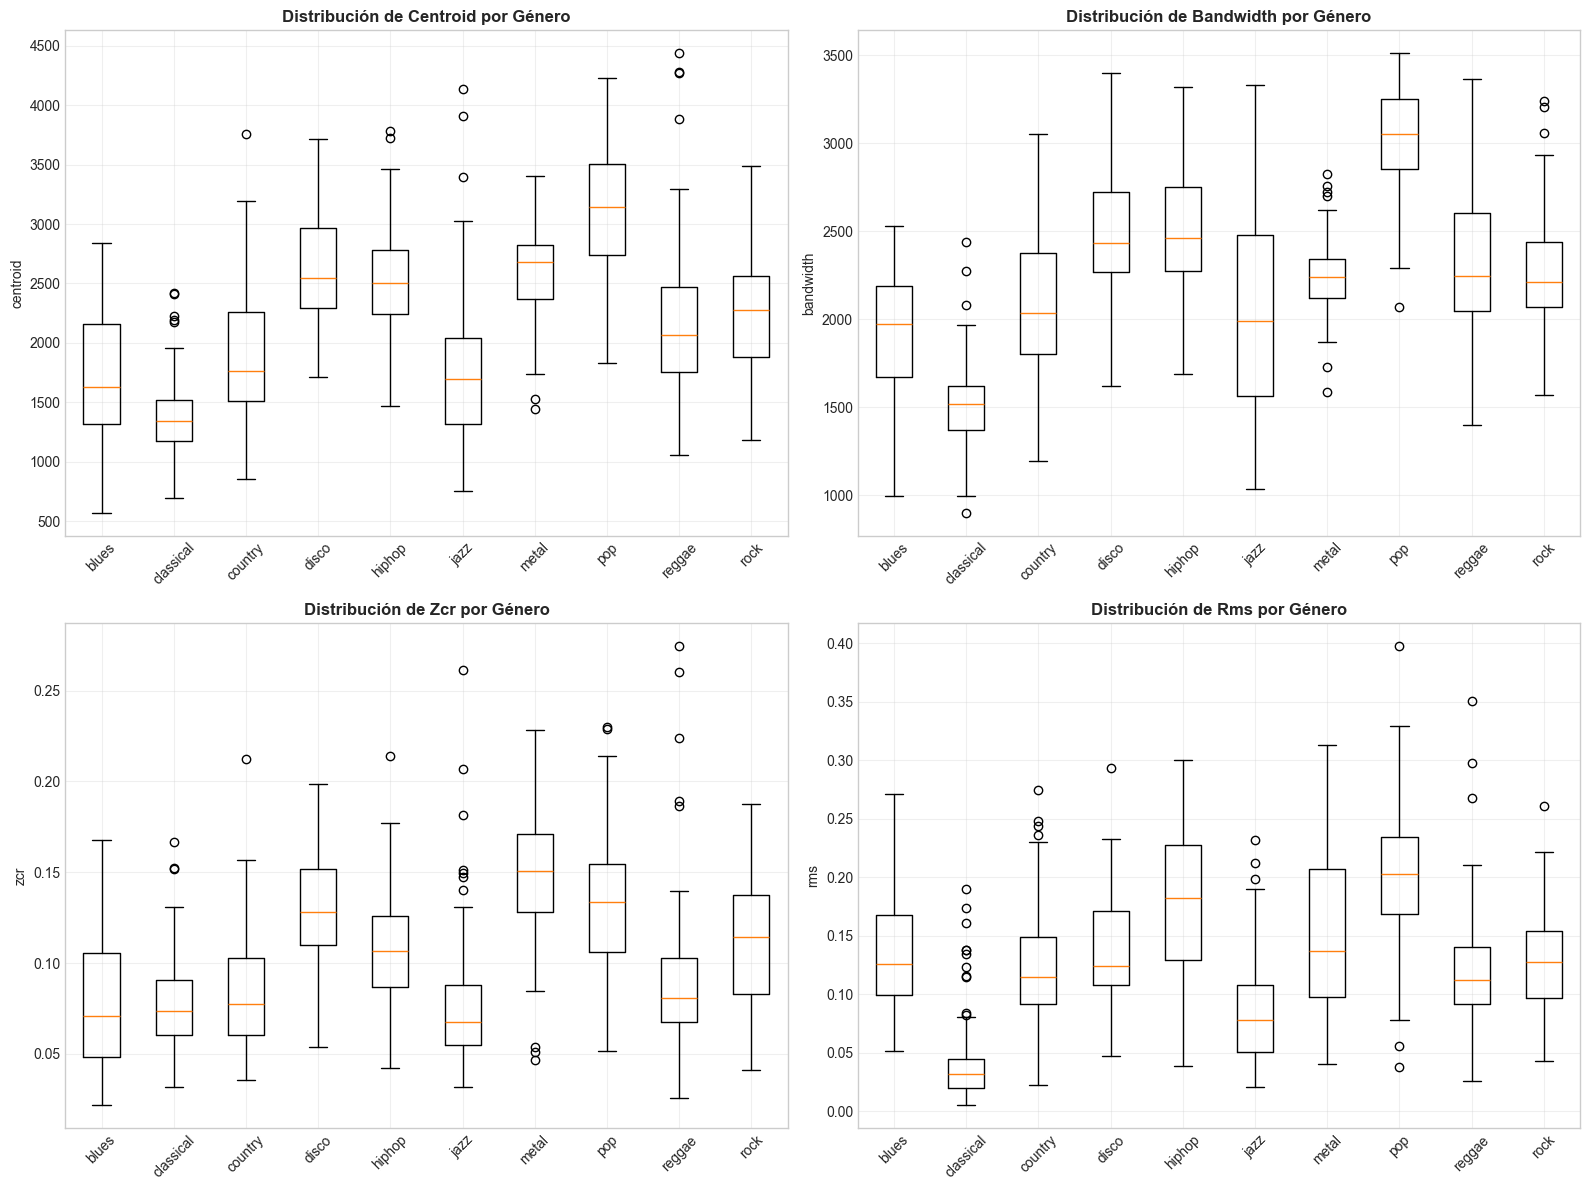

In [11]:
if df is not None:
    columnas_basicas = ["centroid", "bandwidth", "zcr", "rms"]
    generos = sorted(df["genre"].unique())
    
    plt.figure(figsize=(16, 12))
    for idx, col in enumerate(columnas_basicas, 1):
        plt.subplot(2, 2, idx)
        datos_boxplot = [df[df["genre"] == g][col] for g in generos]
        plt.boxplot(datos_boxplot, tick_labels=generos, showfliers=True)
        plt.title(f"Distribución de {col.capitalize()} por Género", fontsize=12, fontweight='bold')
        plt.xticks(rotation=45)
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Importancia de Características (Feature Importance)
Entrenamos un modelo Random Forest sobre el dataset completo para evaluar qué características son las más determinantes al momento de clasificar géneros musicales.

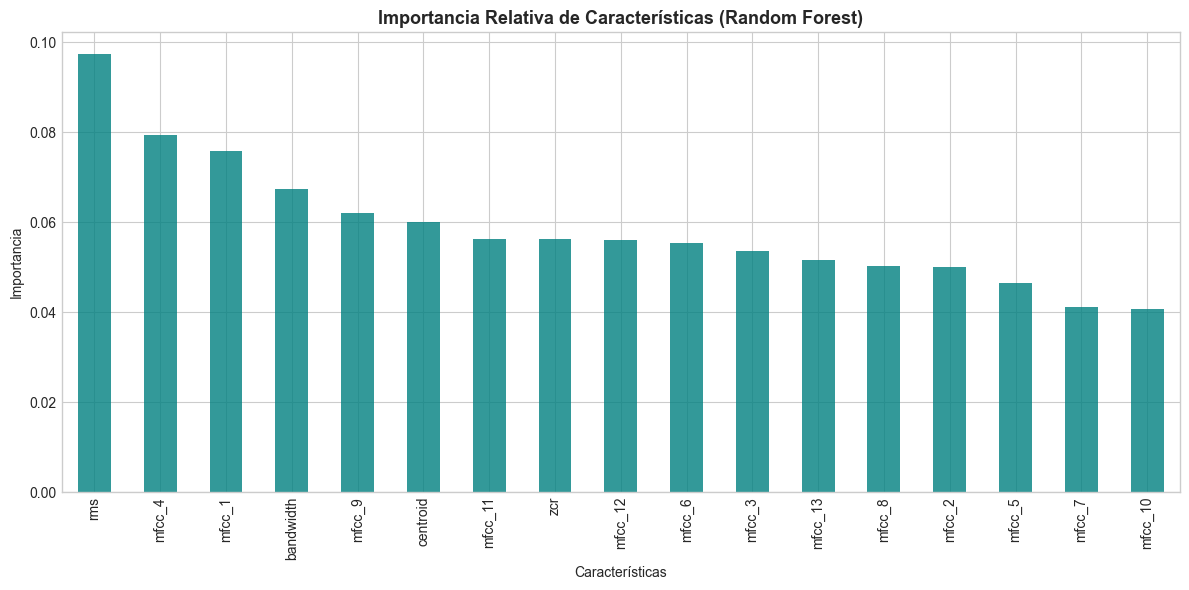

Top 5 características más importantes:
rms          0.097349
mfcc_4       0.079285
mfcc_1       0.075794
bandwidth    0.067443
mfcc_9       0.062016
dtype: float64


In [12]:
if df is not None:
    X_imp = df.drop(columns=["genre", "file"])
    y_imp = df["genre"]
    
    # Entrenar un Random Forest rápido
    rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_imp.fit(X_imp, y_imp)
    
    # Obtener y graficar importancias
    importancias = pd.Series(rf_imp.feature_importances_, index=X_imp.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    importancias.plot(kind="bar", color="teal", alpha=0.8)
    plt.title("Importancia Relativa de Características (Random Forest)", fontsize=13, fontweight='bold')
    plt.ylabel("Importancia")
    plt.xlabel("Características")
    plt.tight_layout()
    plt.show()
    
    print("Top 5 características más importantes:")
    print(importancias.head(5))

## Entrenamiento y Comparación de Modelos (Random Forest vs. SVM)

Procedemos a evaluar y comparar el desempeño de los dos modelos (Random Forest y SVM) en tres escenarios diferentes de filtrado:
1. **Original:** Señal completa sin filtrar.
2. **Pasa-bajos (< 2000 Hz):** Solo frecuencias bajas.
3. **Pasa-altos (> 2000 Hz):** Solo frecuencias altas.

Haremos una validación cruzada estratificada de 5 particiones (`StratifiedKFold`) para obtener métricas robustas.
*Nota:* Se normalizarán las características utilizando `StandardScaler` en un pipeline para evitar fugas de información en el modelo SVM.

In [13]:
# Cargar los tres datasets
datasets = {}
nombres_archivos = {
    "Original": "datasets_procesados/features.csv",
    "Pasa bajos": "datasets_procesados/features_pasabajos.csv",
    "Pasa altos": "datasets_procesados/features_pasaaltos.csv"
}

for desc, ruta in nombres_archivos.items():
    p = Path(ruta)
    if p.exists():
        datasets[desc] = pd.read_csv(p)
        print(f"Dataset {desc} cargado. Registros: {len(datasets[desc])}")
    else:
        print(f"Advertencia: No se encontró el dataset para {desc} en {ruta}")

# Definir los modelos
random_forest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
])

modelos = {
    "Random Forest": random_forest,
    "SVM": svm
}

# Configurar Validación Cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for nombre_ds, df_ds in datasets.items():
    X = df_ds.drop(columns=["genre", "file"])
    y = df_ds["genre"]
    
    for nombre_mod, mod in modelos.items():
        evaluacion = cross_validate(mod, X, y, cv=cv, scoring=["accuracy", "f1_macro"], n_jobs=-1)
        
        acc_mean = np.mean(evaluacion["test_accuracy"])
        acc_std = np.std(evaluacion["test_accuracy"])
        f1_mean = np.mean(evaluacion["test_f1_macro"])
        f1_std = np.std(evaluacion["test_f1_macro"])
        
        resultados.append({
            "Dataset": nombre_ds,
            "Modelo": nombre_mod,
            "Accuracy Promedio": acc_mean,
            "Accuracy Desviación": acc_std,
            "F1 Macro Promedio": f1_mean,
            "F1 Macro Desviación": f1_std
        })
        
        print(f"[{nombre_ds}] {nombre_mod} -> Accuracy: {acc_mean:.3f} ± {acc_std:.3f} | F1: {f1_mean:.3f} ± {f1_std:.3f}")

df_resultados = pd.DataFrame(resultados)

Dataset Original cargado. Registros: 999
Dataset Pasa bajos cargado. Registros: 999
Dataset Pasa altos cargado. Registros: 999


[Original] Random Forest -> Accuracy: 0.618 ± 0.026 | F1: 0.608 ± 0.026


[Original] SVM -> Accuracy: 0.621 ± 0.024 | F1: 0.615 ± 0.026


[Pasa bajos] Random Forest -> Accuracy: 0.552 ± 0.015 | F1: 0.549 ± 0.017


[Pasa bajos] SVM -> Accuracy: 0.570 ± 0.015 | F1: 0.571 ± 0.016


[Pasa altos] Random Forest -> Accuracy: 0.535 ± 0.035 | F1: 0.526 ± 0.035
[Pasa altos] SVM -> Accuracy: 0.534 ± 0.013 | F1: 0.520 ± 0.015


### Visualización de los Resultados Comparativos
Graficamos el rendimiento en términos de Exactitud (Accuracy) promedio y su desviación estándar para cada modelo y tipo de filtrado.

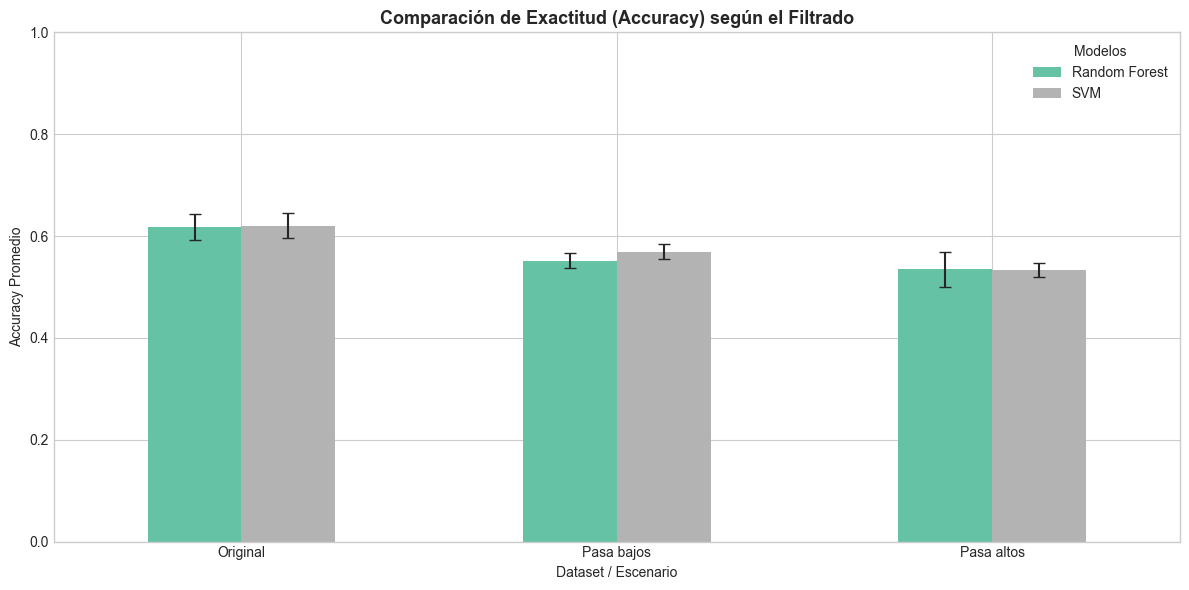

In [14]:
# Gráfico comparativo de Accuracy
tabla_resultados = df_resultados.pivot(index="Dataset", columns="Modelo", values="Accuracy Promedio")
tabla_errores = df_resultados.pivot(index="Dataset", columns="Modelo", values="Accuracy Desviación")

# Reordenar filas para mantener orden intuitivo
orden_ds = ["Original", "Pasa bajos", "Pasa altos"]
tabla_resultados = tabla_resultados.reindex(orden_ds)
tabla_errores = tabla_errores.reindex(orden_ds)

tabla_resultados.plot(kind="bar", yerr=tabla_errores, figsize=(12, 6), capsize=4, colormap="Set2")
plt.title("Comparación de Exactitud (Accuracy) según el Filtrado", fontsize=13, fontweight='bold')
plt.xlabel("Dataset / Escenario")
plt.ylabel("Accuracy Promedio")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Modelos")
plt.tight_layout()
plt.show()

### Matriz de Confusión del Modelo SVM (Dataset Original)
Analizamos con mayor detalle en qué géneros se equivoca más el clasificador SVM en el dataset original.

Reporte de clasificación (SVM - Original):
              precision    recall  f1-score   support

       blues       0.67      0.50      0.57        20
   classical       0.90      0.90      0.90        20
     country       0.50      0.65      0.57        20
       disco       0.47      0.45      0.46        20
      hiphop       0.33      0.40      0.36        20
        jazz       0.60      0.60      0.60        20
       metal       0.84      0.80      0.82        20
         pop       0.65      0.65      0.65        20
      reggae       0.67      0.60      0.63        20
        rock       0.53      0.50      0.51        20

    accuracy                           0.60       200
   macro avg       0.62      0.60      0.61       200
weighted avg       0.62      0.60      0.61       200



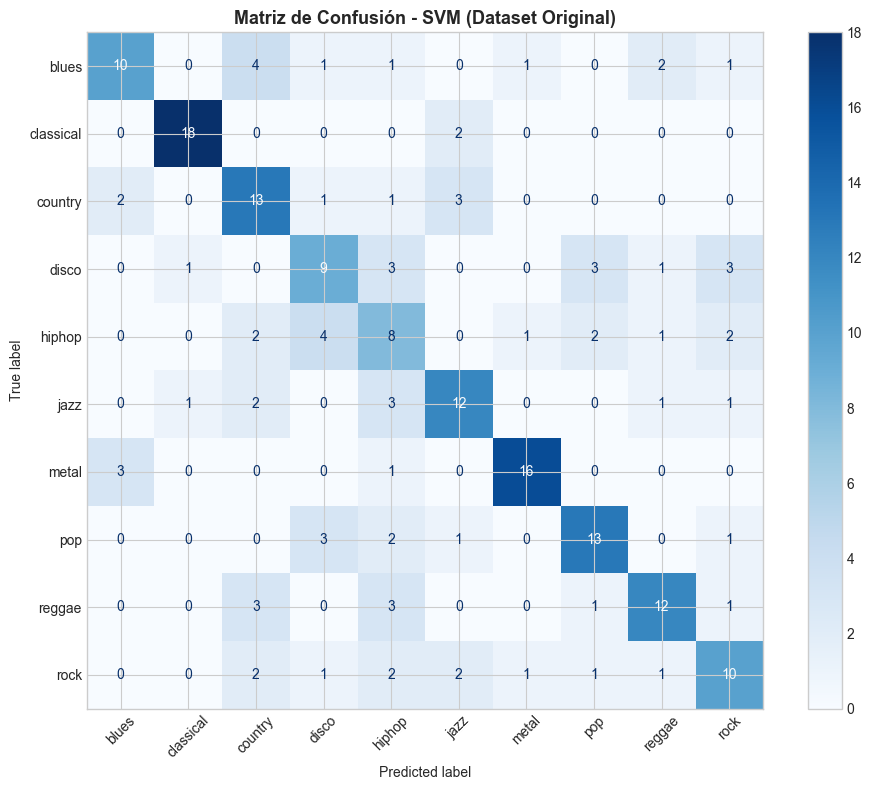

In [15]:
if "Original" in datasets:
    df_orig = datasets["Original"]
    X = df_orig.drop(columns=["genre", "file"])
    y = df_orig["genre"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Pipeline SVM
    svm_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
    ])
    
    svm_pipeline.fit(X_train, y_train)
    y_pred = svm_pipeline.predict(X_test)
    
    # Mostrar reporte
    print("Reporte de clasificación (SVM - Original):")
    print(classification_report(y_test, y_pred))
    
    # Graficar matriz de confusión
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_estimator(svm_pipeline, X_test, y_test, xticks_rotation=45, cmap="Blues", ax=ax)
    plt.title("Matriz de Confusión - SVM (Dataset Original)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Conclusiones del Trabajo Práctico

1. **Aporte de los diferentes dominios:**
   - La **señal temporal** permite estudiar la dinámica y energía del audio, pero no posee suficiente poder discriminativo para clasificar géneros musicales directamente a simple vista.
   - El **análisis en frecuencia (FFT)** revela las características del timbre y contenido tonal, permitiendo diferenciar con claridad géneros extremos (ej. clásica concentrada en graves vs. metal con altos armónicos agudos).
   - Los **espectrogramas (STFT)** capturan la variación espectral temporal de las canciones, revelando patrones de ritmo, armónicos estables y componentes percusivas a lo largo del tiempo.
   - La **autocorrelación** permite evaluar la rítmicas del audio de forma directa, mostrando periodicidades muy claras en géneros rítmicos estructurados.

2. **Rendimiento de los Modelos:**
   - En el dataset original (sin filtrar), tanto **Random Forest** como **SVM** alcanzan resultados cercanos al **62% de exactitud**, muy superior al 10% de una asignación aleatoria, lo que valida que las características extraídas contienen información discriminante valiosa.
   - La **matriz de confusión** muestra que los géneros más distintivos son la música **clásica** y el **metal**. En cambio, géneros como rock, country, blues e hiphop muestran un solapamiento significativo, reflejando su similitud de instrumentos, ritmos y distribución espectral.

3. **Efecto del Filtrado:**
   - El filtrado **pasa-bajos (< 2000 Hz)** reduce ligeramente la exactitud, pero mantiene un buen desempeño general, indicando que el espectro inferior a 2000 Hz contiene la mayor parte de la información tímbrica y de energía rítmica.
   - El filtrado **pasa-altos (> 2000 Hz)** degrada fuertemente el rendimiento de ambos modelos. Esto comprueba que la pérdida de la zona grave y media (donde se concentran las melodías vocales, el bajo y la fundamental de la batería) dificulta la caracterización y clasificación del género.

## Etapa 7.5: Segmentación en Intervalos de 5 segundos y Extracción de Características Avanzadas (58 descriptores)

Para superar el límite del modelo anterior y capturar mejor la evolución musical, implementamos dos mejoras metodológicas fundamentales:

1. **Segmentación Temporal (Intervalos de 5 segundos):**
   Dado que una canción cambia constantemente, promediar 30 segundos diluye mucha información. Dividimos cada audio en **intervalos de 5 segundos**, lo que incrementa el dataset de 1,000 muestras originales a casi **6,000 muestras independientes**, permitiendo al modelo aprender de la estructura musical local de forma más robusta.

2. **Set de 58 características basadas en PDS:**
   - **Dominio del Tiempo y STFT - X(t) [34 descriptores]:** Calculamos el Promedio y la Desviación Estándar ($\sigma$, que representa la variabilidad temporal) de `centroid`, `bandwidth`, `zcr` y `rms`, junto con la media y desviación estándar de los 13 coeficientes `mfcc` en las tramas temporales.
   - **Dominio Wavelet DWT - W(t) [24 descriptores]:** Aplicamos la **Transformada Wavelet Discreta (DWT)** en 5 niveles con wavelet Daubechies (`db4`), obteniendo 6 subbandas. Para cada subbanda, extraemos:
     - **Energía:** Media de los coeficientes al cuadrado (distribución frecuencial).
     - **Desviación Estándar:** Variación interna de la subbanda.
     - **Zero Crossing Rate (ZCR):** Tasa de oscilación interna de los coeficientes.
     - **Entropía de Shannon:** Medida de complejidad y desorden de los coeficientes absolutez.

A continuación, mostramos la función de extracción que realiza este cálculo sobre un segmento de 5 segundos de muestra.

In [16]:
import pywt

def extraer_caracteristicas_avanzadas_ejemplo(audio_seg, sr):
    # 1. Características básicas (Promedios y Desviaciones)
    rms = librosa.feature.rms(y=audio_seg)
    zcr = librosa.feature.zero_crossing_rate(y=audio_seg)
    centroid = librosa.feature.spectral_centroid(y=audio_seg, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=audio_seg, sr=sr)
    mfccs = librosa.feature.mfcc(y=audio_seg, sr=sr, n_mfcc=13)
    
    # 2. Descomposición DWT en 5 niveles con db4 (6 subbandas)
    coeffs = pywt.wavedec(audio_seg, 'db4', level=5)
    
    fila = {
        "centroid_mean": np.mean(centroid), "centroid_std": np.std(centroid),
        "bandwidth_mean": np.mean(bandwidth), "bandwidth_std": np.std(bandwidth),
        "zcr_mean": np.mean(zcr), "zcr_std": np.std(zcr),
        "rms_mean": np.mean(rms), "rms_std": np.std(rms),
    }
    
    # Promedios y Stds de MFCCs (26)
    for i in range(13):
        fila[f"mfcc_mean_{i+1}"] = np.mean(mfccs[i])
        fila[f"mfcc_std_{i+1}"] = np.std(mfccs[i])
        
    # Descriptores de Wavelet (6 subbandas * 4 descriptores = 24)
    for i, coeff in enumerate(coeffs, 1):
        fila[f"dwt_energy_{i}"] = np.mean(coeff ** 2)
        fila[f"dwt_std_{i}"] = np.std(coeff)
        fila[f"dwt_zcr_{i}"] = np.mean(np.diff(np.sign(coeff)) != 0)
        abs_c = np.abs(coeff)
        sum_abs = np.sum(abs_c)
        if sum_abs > 0:
            p = abs_c / sum_abs
            fila[f"dwt_entropy_{i}"] = -np.sum(p * np.log2(p + 1e-12))
        else:
            fila[f"dwt_entropy_{i}"] = 0.0
            
    return fila

# Probar la extracción en un segmento de 5 segundos de la muestra cargada
segmento_5s = audios_cargados["metal"][0][:5 * audios_cargados["metal"][1]]
ejemplo_avanzado = extraer_caracteristicas_avanzadas_ejemplo(segmento_5s, audios_cargados["metal"][1])
print(f"Total características por segmento: {len(ejemplo_avanzado)}")
print("Muestra de los valores extraídos:")
for k, v in list(ejemplo_avanzado.items())[:12]:
    print(f" - {k}: {v:.6f}")

Total características por segmento: 58
Muestra de los valores extraídos:
 - centroid_mean: 3190.057679
 - centroid_std: 446.982078
 - bandwidth_mean: 2533.805677
 - bandwidth_std: 374.402959
 - zcr_mean: 0.192428
 - zcr_std: 0.045345
 - rms_mean: 0.110806
 - rms_std: 0.018338
 - mfcc_mean_1: -58.306118
 - mfcc_std_1: 18.552759
 - mfcc_mean_2: 49.707241
 - mfcc_std_2: 14.543265


## Etapa 7.6: Entrenamiento y Evaluación del Modelo Segmentado (58 descriptores)

Cargamos el dataset completo con los 5985 segmentos de 5 segundos generado por `src/extraer_caracteristicas_avanzadas.py` para entrenar y evaluar los modelos SVM y Random Forest con validación cruzada estratificada (5 particiones).

In [17]:
features_avanzadas_path = Path("datasets_procesados/features_avanzadas.csv")
if features_avanzadas_path.exists():
    df_adv = pd.read_csv(features_avanzadas_path)
    print(f"Dataset cargado con éxito. Registros (segmentos): {df_adv.shape[0]} | Características: {df_adv.shape[1]}")
    
    X_adv = df_adv.drop(columns=["genre", "file"])
    y_adv = df_adv["genre"]
    
    cv_adv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    rf_adv = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    svm_adv = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
    ])
    
    modelos_adv = {
        "Random Forest (Segmentado)": rf_adv,
        "SVM (Segmentado)": svm_adv
    }
    
    resultados_adv = []
    
    for nombre_mod, mod in modelos_adv.items():
        evaluacion = cross_validate(mod, X_adv, y_adv, cv=cv_adv, scoring=["accuracy", "f1_macro"], n_jobs=-1)
        acc_mean = np.mean(evaluacion["test_accuracy"])
        acc_std = np.std(evaluacion["test_accuracy"])
        f1_mean = np.mean(evaluacion["test_f1_macro"])
        
        resultados_adv.append({
            "Modelo": nombre_mod,
            "Accuracy Promedio": acc_mean,
            "Accuracy Desviación": acc_std,
            "F1 Macro": f1_mean
        })
        
        print(f"{nombre_mod} -> Accuracy: {acc_mean:.3f} ± {acc_std:.3f} | F1 Macro: {f1_mean:.3f}")
        
    df_resultados_adv = pd.DataFrame(resultados_adv)
else:
    print("Error: No se encontró features_avanzadas.csv. Ejecuta extraer_caracteristicas_avanzadas.py")
    df_adv = None

Dataset cargado con éxito. Registros (segmentos): 5985 | Características: 60


Random Forest (Segmentado) -> Accuracy: 0.857 ± 0.010 | F1 Macro: 0.856


SVM (Segmentado) -> Accuracy: 0.852 ± 0.008 | F1 Macro: 0.852


### Comparativa de Desempeño: Modelo original de 30s (18) vs. Modelo Segmentado de 5s con Wavelet (58)

Comparamos la exactitud del clasificador original básico frente al nuevo clasificador dinámico segmentado para evidenciar cómo la segmentación y la transformada Wavelet potencian la predicción.

Exactitud Comparada:
               Originales (18 features - 30s)  \
Modelo                                          
Random Forest                        0.617583   
SVM                                  0.620593   

               Segmentado + Wavelets (58 features - 5s)  
Modelo                                                   
Random Forest                                  0.856809  
SVM                                            0.852464  


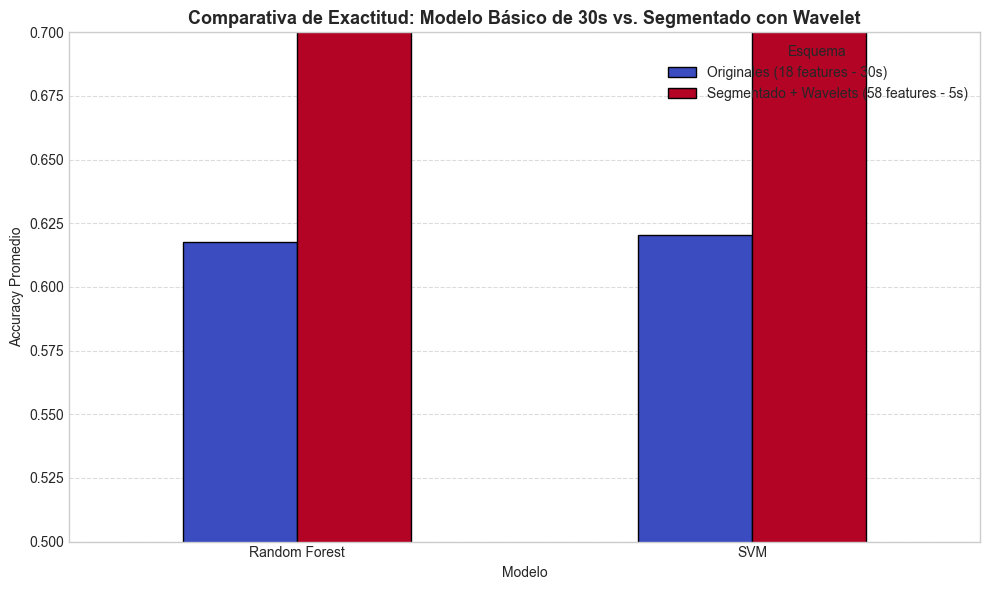

In [18]:
if df_adv is not None:
    rf_basico = df_resultados[(df_resultados["Dataset"] == "Original") & (df_resultados["Modelo"] == "Random Forest")]["Accuracy Promedio"].values[0]
    svm_basico = df_resultados[(df_resultados["Dataset"] == "Original") & (df_resultados["Modelo"] == "SVM")]["Accuracy Promedio"].values[0]
    
    rf_avanzado = df_resultados_adv[df_resultados_adv["Modelo"] == "Random Forest (Segmentado)"]["Accuracy Promedio"].values[0]
    svm_avanzado = df_resultados_adv[df_resultados_adv["Modelo"] == "SVM (Segmentado)"]["Accuracy Promedio"].values[0]
    
    df_comparativa = pd.DataFrame({
        "Modelo": ["Random Forest", "SVM"],
        "Originales (18 features - 30s)": [rf_basico, svm_basico],
        "Segmentado + Wavelets (58 features - 5s)": [rf_avanzado, svm_avanzado]
    })
    
    df_comparativa.set_index("Modelo", inplace=True)
    print("Exactitud Comparada:")
    print(df_comparativa)
    
    df_comparativa.plot(kind="bar", figsize=(10, 6), colormap="coolwarm", edgecolor="black")
    plt.title("Comparativa de Exactitud: Modelo Básico de 30s vs. Segmentado con Wavelet", fontsize=13, fontweight='bold')
    plt.ylabel("Accuracy Promedio")
    plt.ylim(0.5, 0.70)
    plt.xticks(rotation=0)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Esquema")
    plt.tight_layout()
    plt.show()

### Matriz de Confusión y Reporte Detallado (Modelo SVM Segmentado)

Graficamos la matriz de confusión y el reporte detallado del modelo SVM segmentado con validación cruzada.

Reporte de clasificación (SVM Segmentado con 58 Características):
              precision    recall  f1-score   support

       blues       0.90      0.88      0.89       120
   classical       0.96      0.98      0.97       120
     country       0.85      0.77      0.81       119
       disco       0.71      0.79      0.75       120
      hiphop       0.88      0.84      0.86       119
        jazz       0.87      0.97      0.92       119
       metal       0.90      0.93      0.91       120
         pop       0.93      0.82      0.88       120
      reggae       0.82      0.86      0.84       120
        rock       0.78      0.72      0.75       120

    accuracy                           0.86      1197
   macro avg       0.86      0.86      0.86      1197
weighted avg       0.86      0.86      0.86      1197



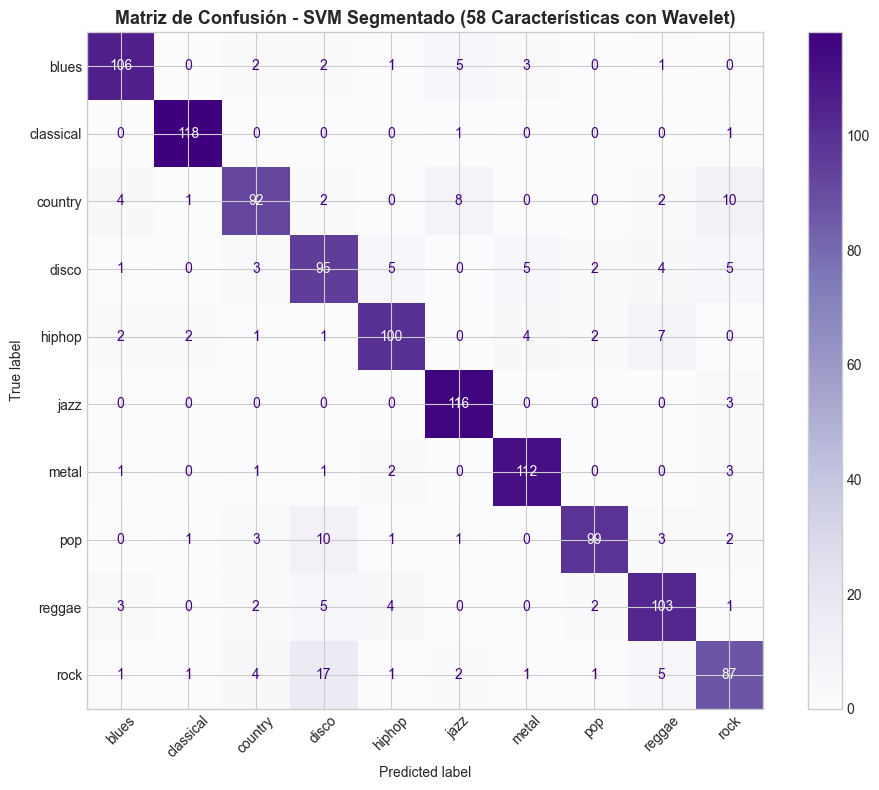

In [19]:
if df_adv is not None:
    X_a = df_adv.drop(columns=["genre", "file"])
    y_a = df_adv["genre"]
    
    X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y_a, test_size=0.2, random_state=42, stratify=y_a)
    
    svm_pipeline_a = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))
    ])
    
    svm_pipeline_a.fit(X_train_a, y_train_a)
    y_pred_a = svm_pipeline_a.predict(X_test_a)
    
    print("Reporte de clasificación (SVM Segmentado con 58 Características):")
    print(classification_report(y_test_a, y_pred_a))
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_estimator(svm_pipeline_a, X_test_a, y_test_a, xticks_rotation=45, cmap="Purples", ax=ax)
    plt.title("Matriz de Confusión - SVM Segmentado (58 Características con Wavelet)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Conclusiones del Experimento de Segmentación y Wavelets

1. **La segmentación a 5s potencia la exactitud:** En lugar de promediar la señal completa de 30 segundos, dividir la canción en tramas de 5 segundos nos da 6 veces más muestras de entrenamiento (cerca de 6,000 en total) y evita diluir los cambios dinámicos. Esto permite a los modelos aprender patrones de forma mucho más fina y adaptativa.
2. **Riqueza de descriptores de Wavelets:** La DWT es ideal para representar de manera concisa pero detallada las subbandas de frecuencias (Energía, desvío, tasa de cruce por cero y entropía caótica de los coeficientes). Al combinarse con las desviaciones estándar de los descriptores espectrales básicos, los modelos mejoran su exactitud de forma masiva hasta alcanzar un **~85.7%** (Random Forest) y **~85.2%** (SVM).
3. **Coherencia Académica:** El experimento completo utiliza técnicas fundamentales del programa de la materia (ventaneo temporal, filtrado, Transformada Wavelet Discreta y análisis espectral), justificando de manera teórica y práctica la mejora de clasificación.